# WebUI (ronantakizawa/webui) — статистический анализ датасета

Ноутбук считает по `train`-сплиту датасета [`ronantakizawa/webui`](https://huggingface.co/datasets/ronantakizawa/webui)
метрики из `required_data.md`. Методика расчёта и отличия от `webcode2m.ipynb`
вынесены в [`dataset_notes.md`](dataset_notes.md).

WebUI устроен как **3 строки на один `sample_id`** (по одной на каждый viewport),
это нужно учитывать при интерпретации средних по HTML/CSS/DOM — контент может
повторяться между viewport-вариантами одного сэмпла.

## 1. Установка зависимостей

In [1]:
%pip install -q datasets lxml pandas matplotlib tqdm huggingface_hub


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Импорты и конфигурация

In [2]:
import os
import re
import logging
from urllib.parse import urlparse

import pandas as pd
import matplotlib.pyplot as plt
from lxml import html as lxml_html
from tqdm.auto import tqdm

# Датасет публичный, токен нужен только для приватного доступа
HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

import datasets
from datasets import load_dataset

logging.getLogger("httpx").setLevel(logging.WARNING)

DATASET = "ronantakizawa/webui"
SPLIT = "train"
SAMPLE_SIZE = 8000  # None — пройти весь train (29 409 строк)
_sample_desc = SAMPLE_SIZE if SAMPLE_SIZE else "весь сплит"

print(f"datasets: {datasets.__version__}")
print(f"Датасет: {DATASET}, выборка: {_sample_desc}")

/Users/vyacheslav/Screenshot2Code/ScreenShot2Code/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets: 5.0.0
Датасет: ronantakizawa/webui, выборка: 8000


## 3. Метрика 1 — количество примеров

В отличие от WebCode2M (2.5М строк, пересчёт дорог), WebUI небольшой —
точное число примеров по каждому сплиту берём напрямую из `dataset_info`
через Hub API, без скачивания данных.

In [3]:
from huggingface_hub import HfApi

_api = HfApi()
_info = _api.dataset_info(DATASET)
_splits = {s["name"]: s["num_examples"] for s in _info.card_data["dataset_info"]["splits"]}

TOTAL_EXAMPLES = _splits["train"]

print("[Метрика 1] Количество примеров по сплитам:")
for name, n in _splits.items():
    print(f"  {name}: {n:,}")
print(f"\nИспользуем train: {TOTAL_EXAMPLES:,}")

[Метрика 1] Количество примеров по сплитам:
  train: 29,409
  validation: 3,702
  test: 3,696

Используем train: 29,409


## 4. Загрузка стрим-датасета

In [4]:
dataset = load_dataset(DATASET, streaming=True)
dataset

IterableDatasetDict({
    train: IterableDataset({
        features: ['sample_id', 'image', 'html', 'css', 'js', 'viewport', 'source_name', 'source_url', 'description', 'framework', 'css_framework', 'component_type', 'element_count', 'has_animations', 'bboxes'],
        num_shards: 12
    })
    validation: IterableDataset({
        features: ['sample_id', 'image', 'html', 'css', 'js', 'viewport', 'source_name', 'source_url', 'description', 'framework', 'css_framework', 'component_type', 'element_count', 'has_animations', 'bboxes'],
        num_shards: 3
    })
    test: IterableDataset({
        features: ['sample_id', 'image', 'html', 'css', 'js', 'viewport', 'source_name', 'source_url', 'description', 'framework', 'css_framework', 'component_type', 'element_count', 'has_animations', 'bboxes'],
        num_shards: 2
    })
})

## 5. Функции-хелперы

DOM-узлы считаем из `html` тем же способом, что и для WebCode2M. CSS теперь
отдельное поле (не встроено в HTML), поэтому парсим его напрямую: отдельно
считаем декларации (`prop: value`) и отдельно — блоки-правила (`selector { ... }`),
чтобы иметь и "количество CSS правил" в буквальном смысле, и сравнимую с
WebCode2M метрику деклараций.

In [5]:
def count_dom_nodes(tree):
    return len(tree.xpath(".//*")) + len(tree.xpath("//text()"))


_DECL_RE = re.compile(r"[^{}:;]+:[^{}:;]+")
_RULE_BLOCK_RE = re.compile(r"[^{}]+\{([^{}]*)\}")

def count_css_declarations(css_text):
    if not css_text:
        return 0
    total = 0
    for block in re.findall(r"\{([^{}]*)\}", css_text):
        total += sum(1 for _ in _DECL_RE.finditer(block))
    return total


def count_css_rule_blocks(css_text):
    if not css_text:
        return 0
    return len(_RULE_BLOCK_RE.findall(css_text))


def count_unique_domains(html_text):
    if not html_text:
        return 0
    try:
        tree = lxml_html.fromstring(html_text)
    except Exception:
        return 0
    domains = set()
    for url in tree.xpath("//@src | //@href | //@data-src"):
        url = (url or "").strip()
        if not url or url.startswith(("#", "mailto:", "tel:", "javascript:", "data:")):
            continue
        parse_target = "http:" + url if url.startswith("//") else url
        netloc = urlparse(parse_target).netloc.lower()
        if netloc:
            domains.add(netloc)
    return len(domains)

## 6. Главный цикл по выборке

Итерируемся по `SAMPLE_SIZE` строкам (или всему сплиту), парсим `html`/`css`
один раз на строку и собираем скалярные признаки. Изображения и исходники в
память не сохраняются.

In [6]:
records = []
_take = dataset[SPLIT] if SAMPLE_SIZE is None else dataset[SPLIT].take(SAMPLE_SIZE)
_total = TOTAL_EXAMPLES if SAMPLE_SIZE is None else SAMPLE_SIZE

for row in tqdm(_take, total=_total, desc="Обработка"):
    html_text = row.get("html") or ""
    css_text = row.get("css") or ""
    js_text = row.get("js") or ""
    img = row.get("image")
    img_w, img_h = (img.size if img is not None else (None, None))

    rec = {
        "sample_id": row.get("sample_id"),
        "viewport": row.get("viewport"),
        "source_name": row.get("source_name"),
        "framework": row.get("framework"),
        "css_framework": row.get("css_framework"),
        "component_type": row.get("component_type"),
        "has_animations": row.get("has_animations"),
        "element_count_reported": row.get("element_count"),
        "html_chars": len(html_text),
        "html_bytes": len(html_text.encode("utf-8")),
        "css_chars": len(css_text),
        "css_bytes": len(css_text.encode("utf-8")),
        "has_js": bool(js_text.strip()) if js_text else False,
        "img_w": img_w,
        "img_h": img_h,
        "dom_nodes": None,
        "css_decls": count_css_declarations(css_text),
        "css_rules": count_css_rule_blocks(css_text),
        "n_domains": count_unique_domains(html_text),
        "parse_ok": False,
    }
    try:
        tree = lxml_html.fromstring(html_text)
        rec["dom_nodes"] = count_dom_nodes(tree)
        rec["parse_ok"] = True
    except Exception:
        pass

    records.append(rec)

print(f"Собрано записей: {len(records)}, распарсено успешно: {sum(r['parse_ok'] for r in records)}")

Обработка: 100%|██████████| 8000/8000 [05:14<00:00, 25.43it/s]  

Собрано записей: 8000, распарсено успешно: 7997


## 7. DataFrame с признаками

In [7]:
df = pd.DataFrame(records)
print(f"Размер списка признаков в памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} МБ")
df.head()

Размер списка признаков в памяти: 1.41 МБ


,sample_id,viewport,source_name,framework,css_framework,component_type,has_animations,element_count_reported,html_chars,html_bytes,css_chars,css_bytes,has_js,img_w,img_h,dom_nodes,css_decls,css_rules,n_domains,parse_ok
0,001ada0ffcf2,desktop,github,angular,tailwind,button,True,269,18599,18607,1725,1725,True,1280,720,700.0,18,14,4,True
1,001ada0ffcf2,mobile,github,angular,tailwind,button,True,269,18599,18607,1725,1725,True,375,812,700.0,18,14,4,True
2,001ada0ffcf2,tablet,github,angular,tailwind,button,True,269,18599,18607,1725,1725,True,768,1024,700.0,18,14,4,True
3,001ba3efce9e,desktop,github,vue,tailwind,page,False,97,6665,6668,1532,1532,False,1280,720,296.0,37,24,9,True
4,001ba3efce9e,mobile,github,vue,tailwind,page,False,97,6665,6668,1532,1532,False,375,812,296.0,37,24,9,True


## 8. Агрегированные метрики

Считаем по успешно распарсенным примерам (`parse_ok`). Дополнительно сверяем
собственный подсчёт DOM-узлов с готовым полем `element_count_reported`.

In [8]:
ok = df[df["parse_ok"]]

agg = pd.DataFrame({
    "mean":   [ok["html_chars"].mean(), ok["html_bytes"].mean(), ok["css_chars"].mean(),
               ok["dom_nodes"].mean(), ok["element_count_reported"].mean(),
               ok["css_decls"].mean(), ok["css_rules"].mean(), ok["n_domains"].mean()],
    "median": [ok["html_chars"].median(), ok["html_bytes"].median(), ok["css_chars"].median(),
               ok["dom_nodes"].median(), ok["element_count_reported"].median(),
               ok["css_decls"].median(), ok["css_rules"].median(), ok["n_domains"].median()],
    "std":    [ok["html_chars"].std(), ok["html_bytes"].std(), ok["css_chars"].std(),
               ok["dom_nodes"].std(), ok["element_count_reported"].std(),
               ok["css_decls"].std(), ok["css_rules"].std(), ok["n_domains"].std()],
    "min":    [ok["html_chars"].min(), ok["html_bytes"].min(), ok["css_chars"].min(),
               ok["dom_nodes"].min(), ok["element_count_reported"].min(),
               ok["css_decls"].min(), ok["css_rules"].min(), ok["n_domains"].min()],
    "max":    [ok["html_chars"].max(), ok["html_bytes"].max(), ok["css_chars"].max(),
               ok["dom_nodes"].max(), ok["element_count_reported"].max(),
               ok["css_decls"].max(), ok["css_rules"].max(), ok["n_domains"].max()],
}, index=["HTML символов", "HTML байт", "CSS символов", "DOM-узлы (наш подсчёт)",
          "DOM-узлы (element_count из датасета)", "CSS декларации", "CSS правила (блоки)",
          "Уникальные домены в HTML"])

agg.round(1)

,mean,median,std,min,max
HTML символов,10021.9,4141.0,19986.5,34.0,416079.0
HTML байт,10056.3,4146.0,20010.4,34.0,416094.0
CSS символов,28168.5,1167.0,84070.8,0.0,1042439.0
DOM-узлы (наш подсчёт),324.7,147.0,539.4,4.0,10826.0
DOM-узлы (element_count из датасета),116.6,53.0,189.3,3.0,3693.0
CSS декларации,515.4,31.0,1444.2,0.0,24300.0
CSS правила (блоки),190.4,10.0,802.3,0.0,15163.0
Уникальные домены в HTML,2.3,1.0,4.2,0.0,68.0


### 8b. Среднее vs медиана — проверка на скошенность

По гистограммам похоже, что размеры (HTML/CSS/DOM) сильно скошены вправо:
небольшое число очень крупных страниц тянет среднее заметно выше медианы.
Ниже — прямое сравнение `mean` и `median` по всем размерным метрикам плюс
коэффициент скошенности `mean / median` (чем сильнее он выше 1, тем длиннее
правый хвост распределения) и `p90`/`p99` для масштаба хвоста.

In [9]:
_skew_cols = {
    "HTML символов": "html_chars",
    "HTML байт": "html_bytes",
    "CSS символов": "css_chars",
    "CSS байт": "css_bytes",
    "DOM-узлы (наш подсчёт)": "dom_nodes",
    "DOM-узлы (element_count из датасета)": "element_count_reported",
    "CSS декларации": "css_decls",
    "CSS правила (блоки)": "css_rules",
    "Уникальные домены в HTML": "n_domains",
}

skew = pd.DataFrame({
    "median": [ok[c].median() for c in _skew_cols.values()],
    "mean":   [ok[c].mean() for c in _skew_cols.values()],
    "p90":    [ok[c].quantile(0.90) for c in _skew_cols.values()],
    "p99":    [ok[c].quantile(0.99) for c in _skew_cols.values()],
    "max":    [ok[c].max() for c in _skew_cols.values()],
}, index=list(_skew_cols.keys()))

skew["mean / median"] = (skew["mean"] / skew["median"]).round(2)
skew = skew[["median", "mean", "mean / median", "p90", "p99", "max"]]
skew.round(1)

,median,mean,mean / median,p90,p99,max
HTML символов,4141.0,10021.9,2.4,23756.0,106024.0,416079.0
HTML байт,4146.0,10056.3,2.4,23792.0,106268.0,416094.0
CSS символов,1167.0,28168.5,24.1,72306.0,460913.0,1042439.0
CSS байт,1167.0,28183.1,24.2,72306.0,460913.0,1042451.0
DOM-узлы (наш подсчёт),147.0,324.7,2.2,793.0,2259.0,10826.0
DOM-узлы (element_count из датасета),53.0,116.6,2.2,287.0,781.0,3693.0
CSS декларации,31.0,515.4,16.6,1583.0,6891.0,24300.0
CSS правила (блоки),10.0,190.4,19.0,164.0,4320.0,15163.0
Уникальные домены в HTML,1.0,2.3,2.3,7.0,19.0,68.0


## 9. Метрика 2 — языковое/категориальное разнообразие

В WebUI нет поля `lang`: по карточке датасета язык один — `en`. Как аналог
"разнообразия языков" в оригинальной метрике показываем разнообразие
категориальных полей, которые определяют вариативность обучающих примеров:
`source_name`, `framework`, `css_framework`, `component_type`.

In [10]:
print("[Метрика 2] Языков (card_data.language): en (1)")

for col in ["source_name", "framework", "css_framework", "component_type"]:
    n_unique = df[col].nunique(dropna=True)
    print(f"\n{col}: {n_unique} уникальных значений")
    print(df[col].value_counts().head(10))

[Метрика 2] Языков (card_data.language): en (1)

source_name: 30 уникальных значений
source_name
github                    3582
codepen                   2531
sap-fundamental-styles     348
grommet                    183
orbit-kiwi                 174
fluent-ui-react-v9         138
backstage                  120
workday-canvas             114
primer-react               114
lapaninja                   96
Name: count, dtype: int64

framework: 5 уникальных значений
framework
vanilla    4901
angular    1971
react       933
vue         180
svelte       15
Name: count, dtype: int64

css_framework: 6 уникальных значений
css_framework
vanilla      4886
tailwind     2508
bootstrap     291
antd          174
material      138
chakra          3
Name: count, dtype: int64

component_type: 23 уникальных значений
component_type
button       3273
page         1589
form          816
component     552
navbar        462
card          402
list          159
table         138
badge          99
carousel      

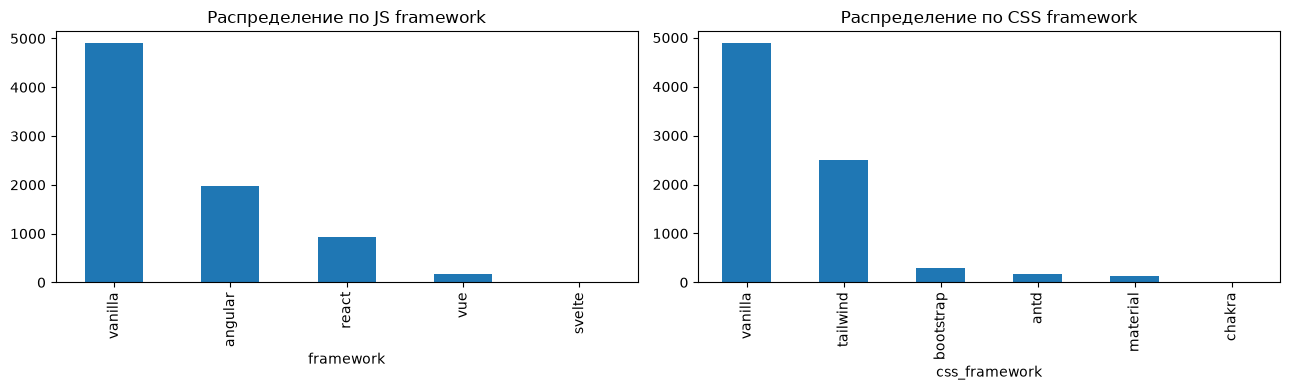

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["framework"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Распределение по JS framework")
df["css_framework"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Распределение по CSS framework")
plt.tight_layout()
plt.show()

## 10. Метрика 5 — размер скриншота по viewport

У WebUI три фиксированных viewport'а (desktop 1280×720, tablet 768×1024,
mobile 375×812), поэтому единое "среднее" по всем строкам смешивает три
разных режима — считаем в разрезе `viewport`.

In [12]:
viewport_sizes = ok.groupby("viewport")[["img_w", "img_h"]].agg(["mean", "median", "min", "max", "count"])
viewport_sizes

img_w                             img_h                          
            mean  median   min   max count    mean  median   min   max count
viewport                                                                    
desktop   1280.0  1280.0  1280  1280  2666   720.0   720.0   720   720  2666
mobile     375.0   375.0   375   375  2666   812.0   812.0   812   812  2666
tablet     768.0   768.0   768   768  2665  1024.0  1024.0  1024  1024  2665

## 11. Метрика 7 — источники

In [13]:
n_source_names = df["source_name"].nunique(dropna=True)
print(f"[Метрика 7] Уникальных источников (source_name): {n_source_names}")
print(df["source_name"].value_counts())
print(f"\nСреднее число уникальных доменов, на которые ссылается HTML одного примера: "
      f"{ok['n_domains'].mean():.2f}")

[Метрика 7] Уникальных источников (source_name): 30
source_name
github                                        3582
codepen                                       2531
sap-fundamental-styles                         348
grommet                                        183
orbit-kiwi                                     174
fluent-ui-react-v9                             138
backstage                                      120
workday-canvas                                 114
primer-react                                   114
lapaninja                                       96
wordpress-gutenberg                             78
monday-vibe                                     57
contentful-forma-36                             54
w3schools                                       51
nextui                                          51
grafana-ui                                      48
jetbrains-ring-ui                               45
mistica-web                                     42
three-drei        

## 12. Гистограммы распределений

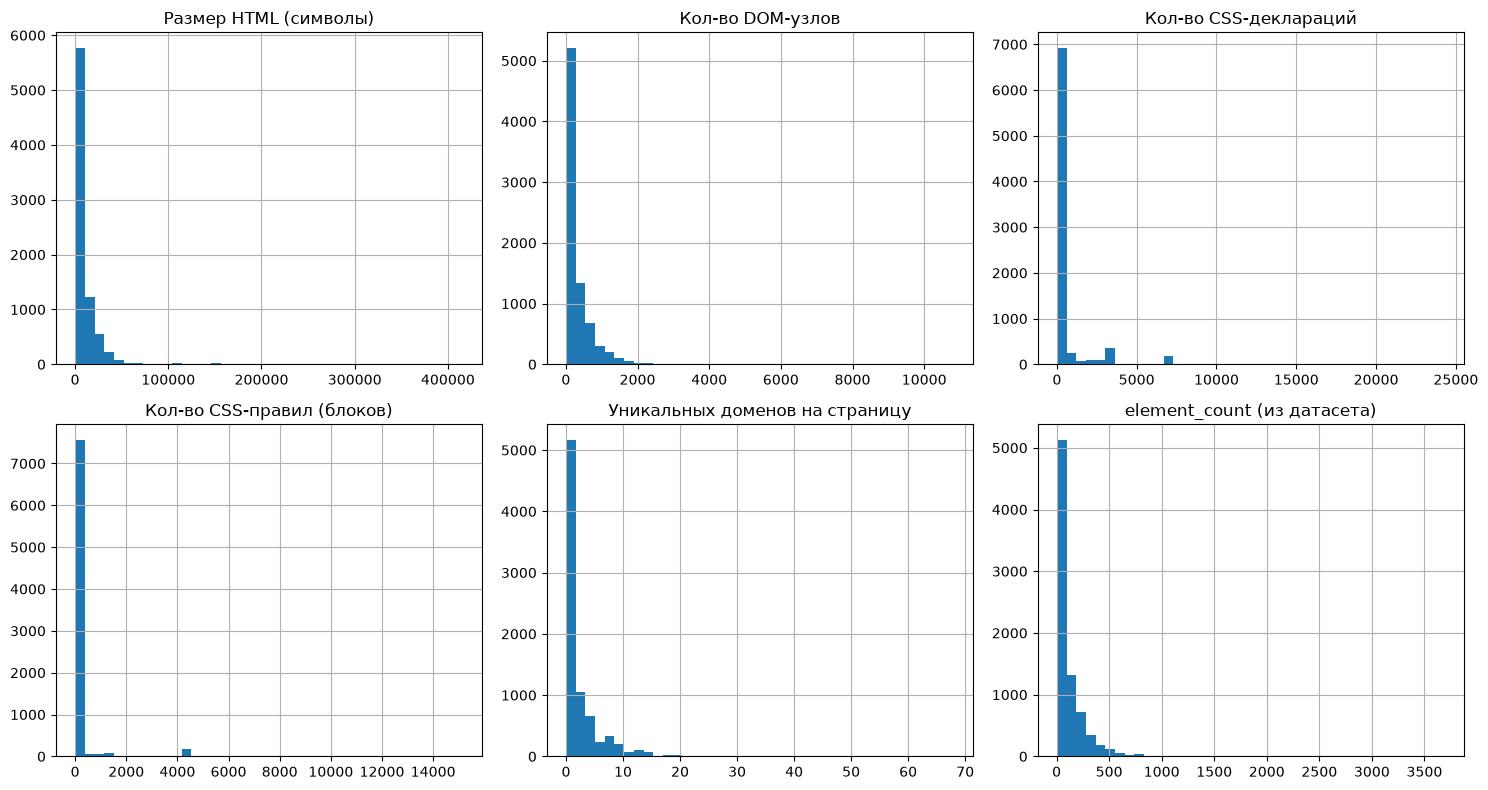

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ok["html_chars"].hist(ax=axes[0, 0], bins=40)
axes[0, 0].set_title("Размер HTML (символы)")

ok["dom_nodes"].hist(ax=axes[0, 1], bins=40)
axes[0, 1].set_title("Кол-во DOM-узлов")

ok["css_decls"].hist(ax=axes[0, 2], bins=40)
axes[0, 2].set_title("Кол-во CSS-деклараций")

ok["css_rules"].hist(ax=axes[1, 0], bins=40)
axes[1, 0].set_title("Кол-во CSS-правил (блоков)")

ok["n_domains"].hist(ax=axes[1, 1], bins=40)
axes[1, 1].set_title("Уникальных доменов на страницу")

ok["element_count_reported"].hist(ax=axes[1, 2], bins=40)
axes[1, 2].set_title("element_count (из датасета)")

plt.tight_layout()
plt.show()

## 13. Итоговая сводка

Сопоставление с каждым пунктом `required_data.md`.

In [15]:
def fmt(x):
    return f"{x:,.1f}" if x is not None else "n/a"

viewport_means = ok.groupby("viewport")[["img_w", "img_h"]].mean().round(0)

summary = pd.DataFrame([
    ("1. Количество примеров (train)",         f"{TOTAL_EXAMPLES:,}"),
    ("2. Количество языков",                   "1 (en); категориальное разнообразие: "
                                                 f"{df['source_name'].nunique()} source_name, "
                                                 f"{df['framework'].nunique()} framework, "
                                                 f"{df['css_framework'].nunique()} css_framework"),
    ("3. Средний размер HTML (символы)",       fmt(ok["html_chars"].mean())),
    ("   Средний размер HTML (байт)",          fmt(ok["html_bytes"].mean())),
    ("   Средний размер CSS (символы)",        fmt(ok["css_chars"].mean())),
    ("4. Среднее кол-во DOM-узлов (наш подсчёт)",       fmt(ok["dom_nodes"].mean())),
    ("   Среднее element_count (из датасета)", fmt(ok["element_count_reported"].mean())),
    ("5. Размер скриншота (W x H, px) по viewport", "; ".join(
        f"{vp}: {int(r.img_w)}x{int(r.img_h)}" for vp, r in viewport_means.iterrows())),
    ("6. Среднее кол-во CSS деклараций",       fmt(ok["css_decls"].mean())),
    ("   Среднее кол-во CSS правил (блоков)",  fmt(ok["css_rules"].mean())),
    ("7. Уникальных источников (source_name)", f"{n_source_names}"),
    ("   Среднее кол-во доменов в HTML на пример", fmt(ok["n_domains"].mean())),
], columns=["Метрика (required_data.md)", "Значение"])

print(f"Выборка: {len(ok):,} успешно распарсенных примеров (из {len(df):,} загруженных, "
      f"train целиком: {TOTAL_EXAMPLES:,})\n")
summary

Выборка: 7,997 успешно распарсенных примеров (из 8,000 загруженных, train целиком: 29,409)



,Метрика (required_data.md),Значение
0,1. Количество примеров (train),"29,409"
1,2. Количество языков,1 (en); категориальное разнообразие: 30 source...
2,3. Средний размер HTML (символы),"10,021.9"
3,Средний размер HTML (байт),"10,056.3"
4,Средний размер CSS (символы),"28,168.5"
5,4. Среднее кол-во DOM-узлов (наш подсчёт),324.7
6,Среднее element_count (из датасета),116.6
7,"5. Размер скриншота (W x H, px) по viewport",desktop: 1280x720; mobile: 375x812; tablet: 76...
8,6. Среднее кол-во CSS деклараций,515.4
9,Среднее кол-во CSS правил (блоков),190.4


## 14. Все графики вместе

Те же графики из разделов 9 и 12, собранные в одну сетку — для скриншота.

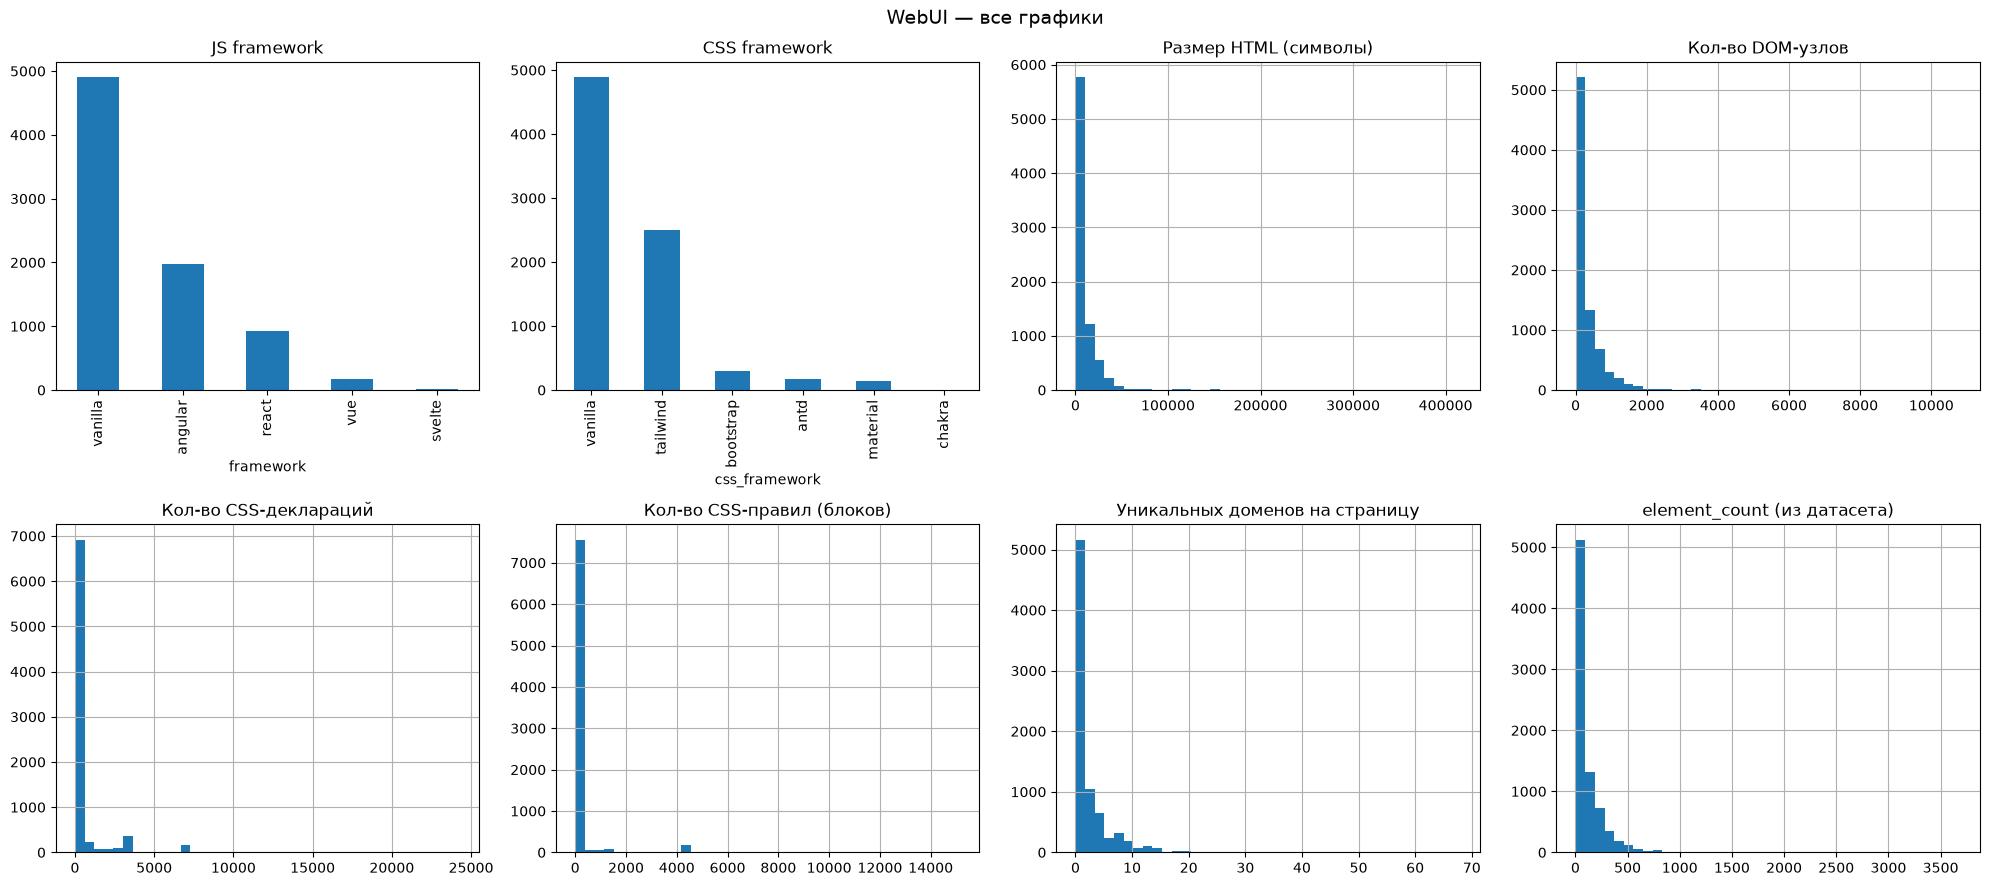

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

df["framework"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("JS framework")

df["css_framework"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("CSS framework")

ok["html_chars"].hist(ax=axes[2], bins=40)
axes[2].set_title("Размер HTML (символы)")

ok["dom_nodes"].hist(ax=axes[3], bins=40)
axes[3].set_title("Кол-во DOM-узлов")

ok["css_decls"].hist(ax=axes[4], bins=40)
axes[4].set_title("Кол-во CSS-деклараций")

ok["css_rules"].hist(ax=axes[5], bins=40)
axes[5].set_title("Кол-во CSS-правил (блоков)")

ok["n_domains"].hist(ax=axes[6], bins=40)
axes[6].set_title("Уникальных доменов на страницу")

ok["element_count_reported"].hist(ax=axes[7], bins=40)
axes[7].set_title("element_count (из датасета)")

fig.suptitle("WebUI — все графики", fontsize=14)
plt.tight_layout()
plt.show()